In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
import sys
sys.path.append("src")

from kpsa import kpsa
from pso import pso
from benchmark_functions import sphere, rastrigin, ackley, rosenbrock, griewank, schwefel, levy

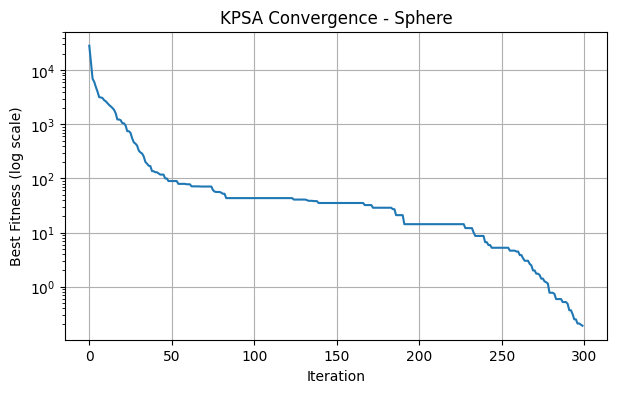

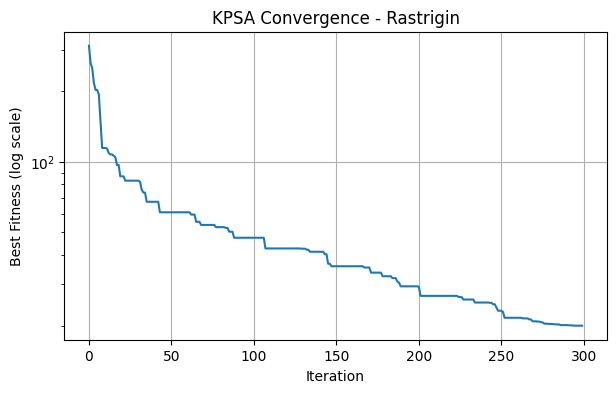

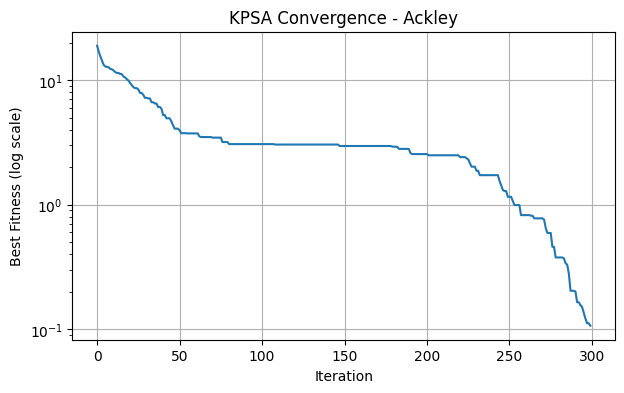

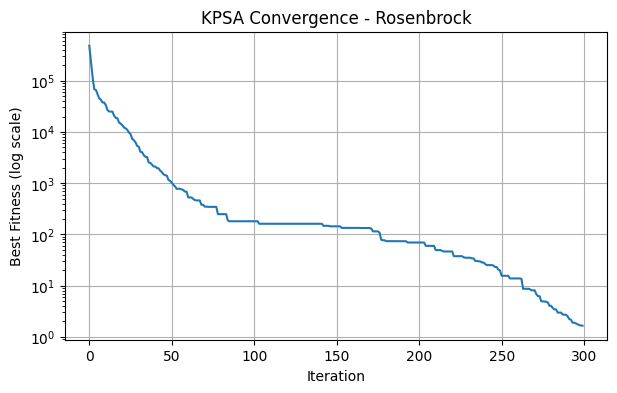

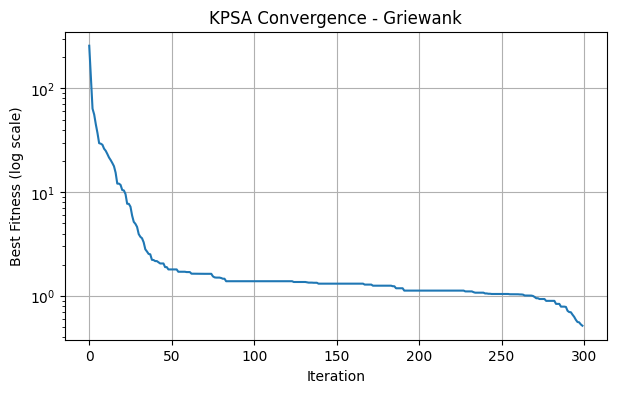

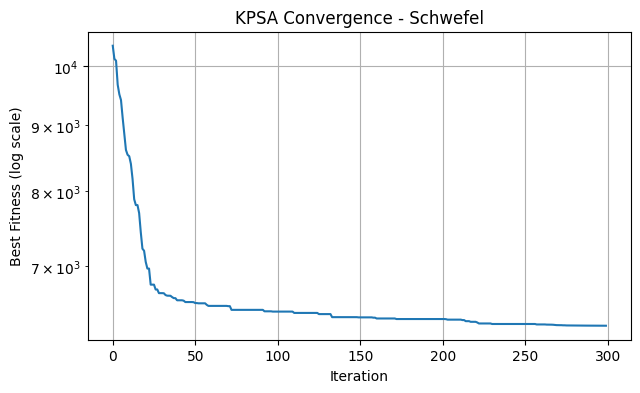

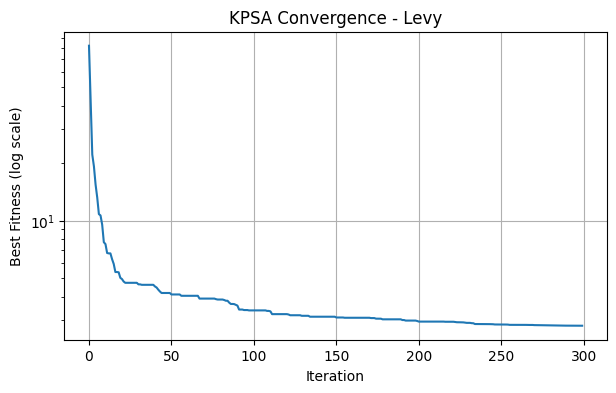

In [66]:
functions = {
    "Sphere": (sphere, (-100, 100)),
    "Rastrigin": (rastrigin, (-5.12, 5.12)),
    "Ackley": (ackley, (-32.768, 32.768)),
    "Rosenbrock": (rosenbrock, (-5, 10)),
    "Griewank": (griewank, (-600, 600)),
    "Schwefel": (schwefel, (-500, 500)),
    "Levy": (levy, (-10, 10)),
}

for name, (func, bound) in functions.items():
    _, f_best, hist, psi_hist, crisis_count = kpsa(
        objective=func, dim=30, bounds=bound,
        n_agents=50, max_iter=300, seed=42
    )

    plt.figure(figsize=(7, 4))
    plt.plot(hist)
    plt.yscale("log")
    plt.title(f"KPSA Convergence - {name}")
    plt.xlabel("Iteration")
    plt.ylabel("Best Fitness (log scale)")
    plt.grid(True)

    plt.savefig(f"results/convergence_plots/kpsa_convergence_{name.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

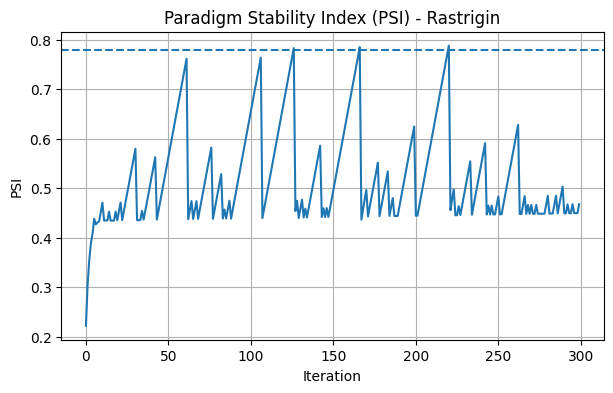

In [67]:
func, bound = functions["Rastrigin"]

_, f_best, hist, psi_hist, crisis_count = kpsa(
    objective=func, dim=30, bounds=bound,
    n_agents=50, max_iter=300, seed=42
)

plt.figure(figsize=(7, 4))
plt.plot(psi_hist)
plt.axhline(0.78, linestyle="--")
plt.title("Paradigm Stability Index (PSI) - Rastrigin")
plt.xlabel("Iteration")
plt.ylabel("PSI")
plt.grid(True)

plt.savefig("results/convergence_plots/psi_rastrigin.png", dpi=300, bbox_inches="tight")
plt.show()

In [68]:
summary = []

for name, (func, bound) in functions.items():
    for seed in range(30):
        _, kpsa_fit, _, _, crisis = kpsa(
            objective=func, dim=30, bounds=bound,
            n_agents=50, max_iter=300, seed=seed
        )

        _, pso_fit, _ = pso(
            objective=func, dim=30, bounds=bound,
            n_particles=50, max_iter=300, seed=seed
        )

        summary.append({
            "Function": name,
            "Seed": seed,
            "KPSA": kpsa_fit,
            "PSO": pso_fit,
            "Crisis": crisis
        })

df_summary = pd.DataFrame(summary)
df_summary.to_csv("results/statistical_results.csv", index=False)
df_summary.head()

,Function,Seed,KPSA,PSO,Crisis
0,Sphere,0,0.093593,0.001687,4
1,Sphere,1,0.110462,0.000422,3
2,Sphere,2,0.111336,0.000067,3
3,Sphere,3,0.098271,0.001616,4
4,Sphere,4,0.059170,0.000261,3


In [69]:
summary_table = df_summary.groupby("Function")[["KPSA", "PSO", "Crisis"]].agg(["mean", "std", "min", "max"])
summary_table.to_csv("results/summary_results.csv")
summary_table

KPSA                                                  PSO  \
                   mean          std          min          max          mean   
Function                                                                       
Ackley         0.486308     0.586362     0.049385     2.427479      3.255522   
Griewank       0.444980     0.136677     0.238932     0.716313      6.054306   
Levy           5.045729     2.479235     1.093638    10.172052      9.318834   
Rastrigin     52.044766    17.317998    28.910486    92.635816    102.939725   
Rosenbrock    92.135717    44.775145     5.952561   185.180046  24398.294826   
Schwefel    5861.376831  1203.941106  3854.868363  8193.791378   3784.632262   
Sphere         0.125148     0.040909     0.059170     0.221580    666.669067   

                                                        Crisis                \
                     std          min            max      mean       std min   
Function                                                                       
Ackley          4.119678     0.008512      15.176399  3.633333  1.496740   2   
Griewank       22.952832     0.000073      90.517704  3.266667  1.311312   1   
Levy            7.788121     0.544824      29.428672  2.466667  1.525266   0   
Rastrigin      29.003100    40.849306     154.283793  3.833333  1.683251   0   
Rosenbrock  34480.414678    24.147143  111043.488082  1.800000  1.186127   0   
Schwefel      705.576266  2518.893156    5639.057904  3.833333  0.985527   2   
Sphere       2537.080728     0.000067   10000.000334  3.200000  1.297212   1   

                
           max  
Function        
Ackley       7  
Griewank     5  
Levy         5  
Rastrigin    7  
Rosenbrock   4  
Schwefel     6  
Sphere       5

In [70]:
df_summary["Winner"] = np.where(df_summary["KPSA"] < df_summary["PSO"], "KPSA", "PSO")

win_rate = (
    df_summary
    .groupby("Function")["Winner"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

win_rate.to_csv("results/win_rate.csv")
win_rate

Winner,KPSA,PSO
Function,,
Ackley,0.833333,0.166667
Griewank,0.066667,0.933333
Levy,0.633333,0.366667
Rastrigin,0.900000,0.100000
Rosenbrock,0.733333,0.266667
Schwefel,0.000000,1.000000
Sphere,0.066667,0.933333


In [71]:
from scipy.stats import wilcoxon

wilcoxon_results = []

for name in df_summary["Function"].unique():
    temp = df_summary[df_summary["Function"] == name]
    stat, p = wilcoxon(temp["KPSA"], temp["PSO"])

    wilcoxon_results.append({
        "Function": name,
        "Statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results)
df_wilcoxon.to_csv("results/wilcoxon_results.csv", index=False)
df_wilcoxon

,Function,Statistic,p_value
0,Sphere,59.0,1.528710e-04
1,Rastrigin,16.0,3.147870e-07
2,Ackley,32.0,5.144626e-06
3,Rosenbrock,72.0,5.548261e-04
4,Griewank,59.0,1.528710e-04
5,Schwefel,0.0,1.862645e-09
6,Levy,107.0,8.705463e-03


In [75]:
direction_results = []

for name in df_summary["Function"].unique():
    temp = df_summary[df_summary["Function"] == name]

    kpsa_median = temp["KPSA"].median()
    pso_median = temp["PSO"].median()

    better = "KPSA" if kpsa_median < pso_median else "PSO"

    direction_results.append({
        "Function": name,
        "KPSA Median": kpsa_median,
        "PSO Median": pso_median,
        "Better by Median": better
    })

df_direction = pd.DataFrame(direction_results)
df_direction.to_csv("results/direction_results.csv", index=False)
df_direction

,Function,KPSA Median,PSO Median,Better by Median
0,Sphere,0.117675,0.000713,PSO
1,Rastrigin,50.305817,104.020376,KPSA
2,Ackley,0.161333,2.271268,KPSA
3,Rosenbrock,74.665401,1017.600616,KPSA
4,Griewank,0.438762,0.012503,PSO
5,Schwefel,5779.312582,3707.995315,PSO
6,Levy,4.739047,8.668924,KPSA


In [74]:
robust_summary = (
    df_summary
    .groupby("Function")
    .agg(
        KPSA_mean=("KPSA", "mean"),
        KPSA_median=("KPSA", "median"),
        KPSA_std=("KPSA", "std"),
        KPSA_min=("KPSA", "min"),
        KPSA_max=("KPSA", "max"),

        PSO_mean=("PSO", "mean"),
        PSO_median=("PSO", "median"),
        PSO_std=("PSO", "std"),
        PSO_min=("PSO", "min"),
        PSO_max=("PSO", "max"),

        Crisis_mean=("Crisis", "mean")
    )
    .reset_index()
)

robust_summary.to_csv("results/robust_summary_results.csv", index=False)
robust_summary

,Function,KPSA_mean,KPSA_median,KPSA_std,KPSA_min,KPSA_max,PSO_mean,PSO_median,PSO_std,PSO_min,PSO_max,Crisis_mean
0,Ackley,0.486308,0.161333,0.586362,0.049385,2.427479,3.255522,2.271268,4.119678,0.008512,15.176399,3.633333
1,Griewank,0.444980,0.438762,0.136677,0.238932,0.716313,6.054306,0.012503,22.952832,0.000073,90.517704,3.266667
2,Levy,5.045729,4.739047,2.479235,1.093638,10.172052,9.318834,8.668924,7.788121,0.544824,29.428672,2.466667
3,Rastrigin,52.044766,50.305817,17.317998,28.910486,92.635816,102.939725,104.020376,29.003100,40.849306,154.283793,3.833333
4,Rosenbrock,92.135717,74.665401,44.775145,5.952561,185.180046,24398.294826,1017.600616,34480.414678,24.147143,111043.488082,1.800000
5,Schwefel,5861.376831,5779.312582,1203.941106,3854.868363,8193.791378,3784.632262,3707.995315,705.576266,2518.893156,5639.057904,3.833333
6,Sphere,0.125148,0.117675,0.040909,0.059170,0.221580,666.669067,0.000713,2537.080728,0.000067,10000.000334,3.200000
